In [1]:
# ! pip install -e ../../savo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from copy import deepcopy as copy
from scipy import optimize
import torch

import sys
sys.path.append('../')  #for savo import
sys.path.append('../../machineIO/')  #for machineIO import
from savo.model import GaussianProcess as GP
from machineIO.util import plot_2D_projection

Failed to import 'epics'
Failed to import 'phantasy'


In [3]:
x0 = -1.0*torch.ones(2)
# x0[0] = -1.0
# x0[1] =  1.0
x0[0] =  0.1
x0[1] =  1.0

In [4]:
def quadratic(x, noise=0.0):
    x = torch.as_tensor(x)
    d = x.shape[-1]
    y = torch.sum(x**2, dim=-1) / d
    return 1 - y + torch.randn_like(y) * noise

In [5]:
def rosenbrock(x, noise=0.0):
    x = torch.as_tensor(x)
    y = (x[:,1] - x[:,0]**2)**2 + (1 - x[:,0])**2/100
    return 1- y  + torch.randn_like(y) * noise

In [6]:
def rastrigin(x, noise=0.0):
    x = torch.as_tensor(x)
    y = 10*2 + (x[:,0]**2 - 10*torch.cos(2*np.pi*x[:,0])) + (x[:,1]**2 - 10*torch.cos(2*np.pi*x[:,1]))
    return 1 - y/40  + torch.randn_like(y) * noise 

In [7]:
def goldstein_price(x, noise=0.0):
    x = torch.as_tensor(x)
    y = (1 + (x[:,0] + x[:,1] + 1)**2 * (19 - 14*x[:,0] + 3*x[:,0]**2 - 14*x[:,1] + 6*x[:,0]*x[:,1] + 3*x[:,1]**2)) * \
        (30 + (2*x[:,0] - 3*x[:,1])**2 * (18 - 32*x[:,0] + 12*x[:,0]**2 + 48*x[:,1] - 36*x[:,0]*x[:,1] + 27*x[:,1]**2)) 
    return 1 - torch.log(1+y)/10.0  + torch.randn_like(y) * noise 

In [8]:
# test_func = quadratic
# test_func = rosenbrock
# test_func = rastrigin
test_func = goldstein_price

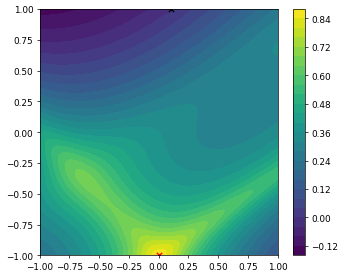

In [ ]:
# Updated plot_contour function to support multiple subplots
def plot_contour(figsize=(6,5), dpi=256, ncols=1, nrows=1):
    gridx = np.linspace(-1,1,256)
    gridy = np.linspace(-1,1,256)
    x1,x2 = np.meshgrid(gridx,gridy)
    xgrid = np.vstack((x1.flatten(), x2.flatten())).T
    ygrid = test_func(xgrid,noise=0)
    
    if ncols == 1 and nrows == 1:
        # Backward compatible: single subplot
        fig,ax = plt.subplots(figsize=figsize,dpi=dpi)
        cs = ax.tricontourf(xgrid[:,0],xgrid[:,1],ygrid,levels=32)
        fig.colorbar(cs,ax=ax)
        return fig,ax
    else:
        # Multiple subplots
        fig,axes = plt.subplots(nrows, ncols, figsize=figsize, dpi=dpi)
        if ncols * nrows == 1:
            axes = [axes]
        elif nrows == 1:
            axes = axes.flatten()
        else:
            axes = axes.flatten()
        
        # Add individual colorbar for each subplot
        for ax in axes:
            cs = ax.tricontourf(xgrid[:,0],xgrid[:,1],ygrid,levels=32)
            fig.colorbar(cs, ax=ax, shrink=0.8)
            
        return fig,axes
fig,ax = plot_contour(dpi=64)
ax.scatter(x0[0],x0[1],marker='x',c='k')
ax.scatter(0,-1,marker='x',c='r')

In [10]:
def get_grad(f, x):
    x_ = x.clone().requires_grad_(True)
    y = f(x_)
    y = y.sum()
    y.backward()
    dydx = x_.grad
    return dydx

# get gradient trajectory

In [36]:
import torch.nn.functional as F

n_budget = 45
n_init = 20
lr = 0.4
train_x = torch.zeros(n_budget, 2)
train_xES = torch.zeros(n_budget, 2)
train_y = torch.zeros(n_budget, 1)
train_yES = torch.zeros(n_budget, 1)
grad_true = torch.zeros_like(train_x)
grad_true_ES = torch.zeros_like(train_x)  # Added grad_true_ES
grad_pred = torch.zeros_like(train_x)
grad_pred_ES = torch.zeros_like(train_x)
grad_var = torch.zeros(n_budget)
grad_var_ES = torch.zeros(n_budget)

# Cosine similarity arrays
cos_sim_pred_true = torch.zeros(n_budget)  # cos(grad_pred, grad_true)
cos_sim_pred_ES_true_ES = torch.zeros(n_budget)  # cos(grad_pred_ES, grad_true_ES)

train_x[0] = x0
train_xES[0] = x0

for i in range(n_budget):
    train_y[i] = test_func(train_x[i:i+1])
    train_yES[i] = test_func(train_xES[i:i+1])
    grad_true[i] = get_grad(test_func, train_x[i:i+1])
    grad_true_ES[i] = get_grad(test_func, train_xES[i:i+1])  # Added grad_true_ES computation
    
    if i < n_budget-1:
        train_x[i+1] = train_x[i] + lr*grad_true[i]
        train_xES[i+1] = train_xES[i] + lr*grad_true[i] 
        train_xES[i+1][0] += 0.05*np.sin(2*torch.pi*0.33*i)
        train_xES[i+1][1] += 0.05*np.sin(2*torch.pi*0.66*i)
    
    if i >= n_init:
        gp = GP(train_x[:i+1], train_y[:i+1])
        grad_pred[i] = gp.get_grad(train_x[i:i+1])
        grad_var[i] = gp.get_gradient_covariance_trace(train_x[i:i+1])
        
        gp = GP(train_xES[:i+1], train_yES[:i+1])
        grad_pred_ES[i] = gp.get_grad(train_xES[i:i+1])
        grad_var_ES[i] = gp.get_gradient_covariance_trace(train_xES[i:i+1])
        
        # Compute cosine similarities
        cos_sim_pred_true[i] = F.cosine_similarity(
            grad_pred[i:i+1], grad_true[i:i+1], dim=1
        )[0]
        
        cos_sim_pred_ES_true_ES[i] = F.cosine_similarity(
            grad_pred_ES[i:i+1], grad_true_ES[i:i+1], dim=1
        )[0]

# Print some statistics
print(f"Average cosine similarity (grad_pred vs grad_true): {cos_sim_pred_true[n_init:].mean():.4f}")
print(f"Average cosine similarity (grad_pred_ES vs grad_true_ES): {cos_sim_pred_ES_true_ES[n_init:].mean():.4f}")
print(f"Standard deviation (grad_pred vs grad_true): {cos_sim_pred_true[n_init:].std():.4f}")
print(f"Standard deviation (grad_pred_ES vs grad_true_ES): {cos_sim_pred_ES_true_ES[n_init:].std():.4f}")

Average cosine similarity (grad_pred vs grad_true): 0.5274
Average cosine similarity (grad_pred_ES vs grad_true_ES): 0.9847
Standard deviation (grad_pred vs grad_true): 0.2275
Standard deviation (grad_pred_ES vs grad_true_ES): 0.0186


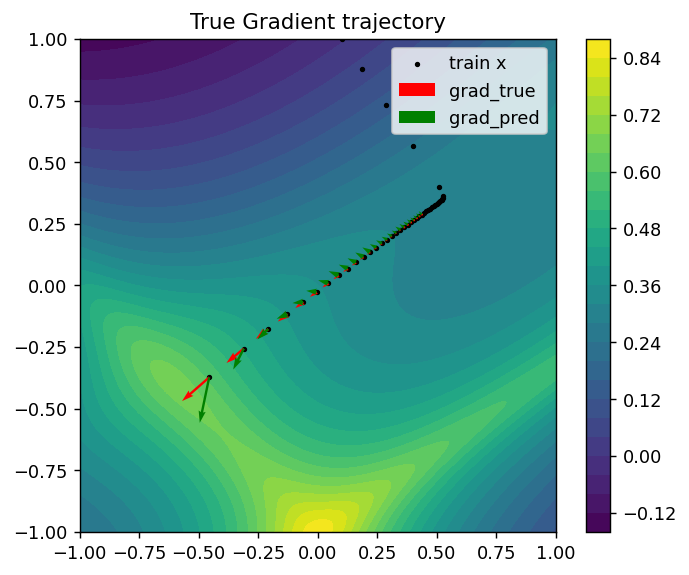

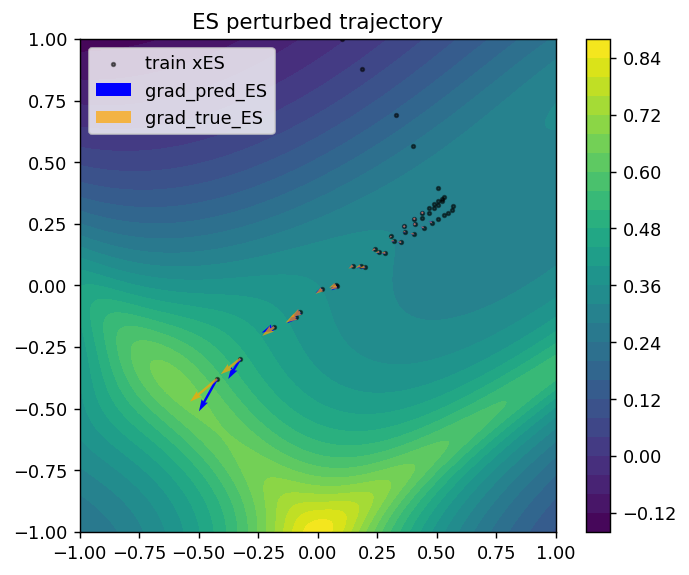

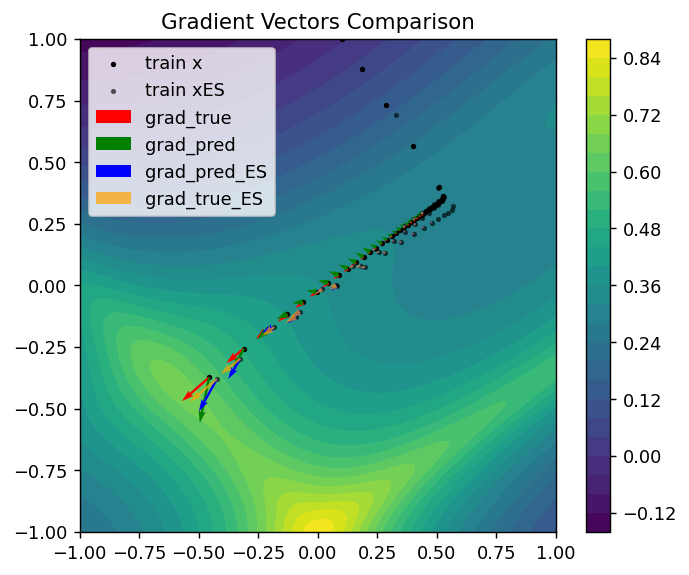

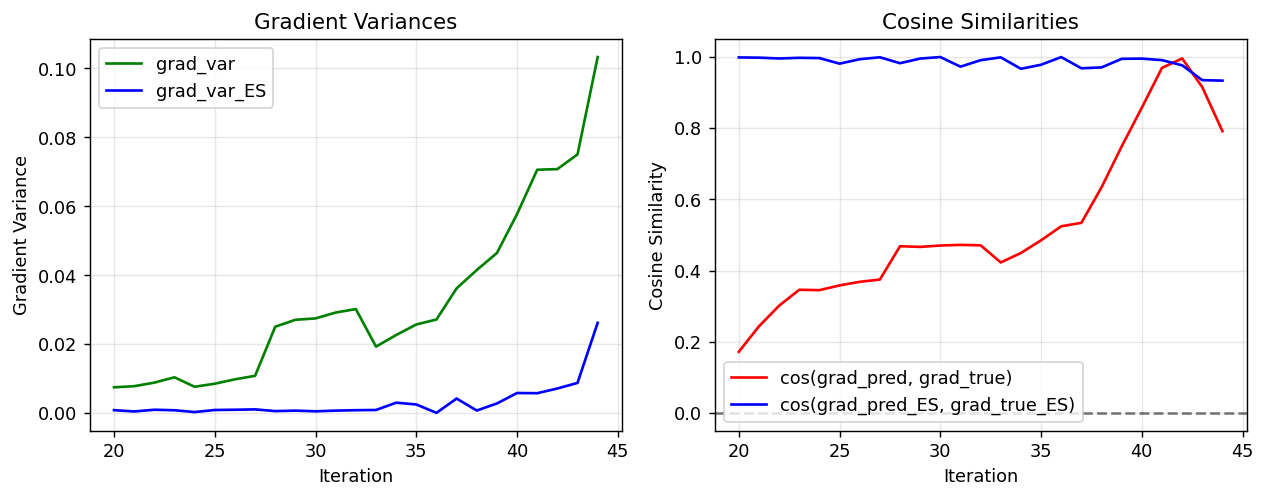

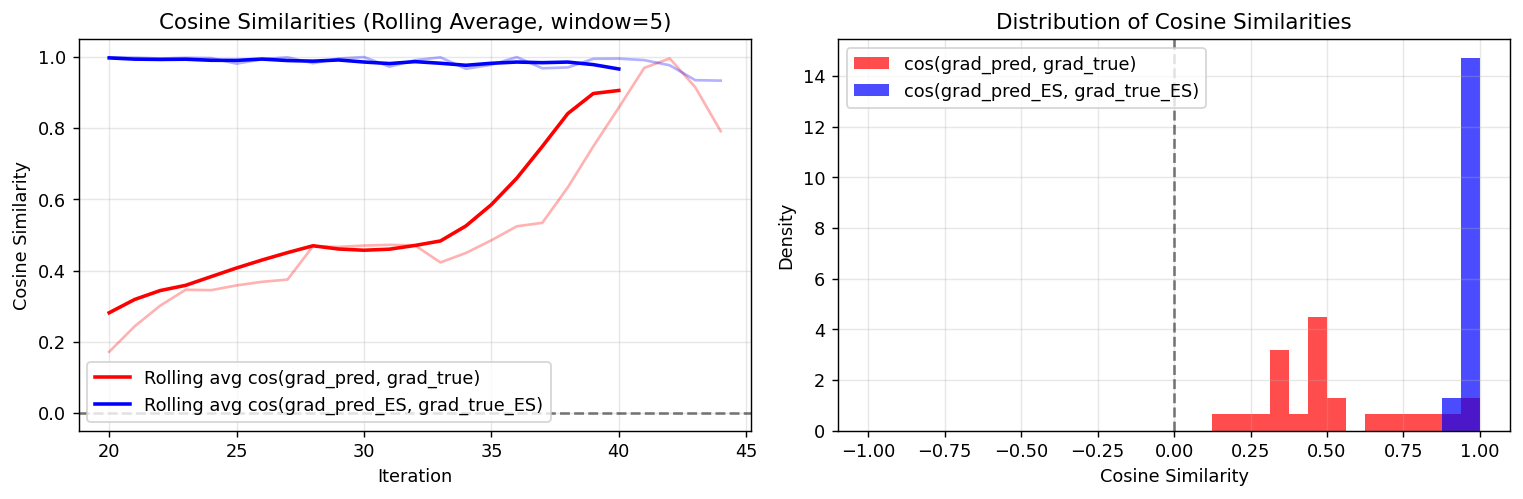


SUMMARY STATISTICS
Average cosine similarity (grad_pred vs grad_true): 0.5274 ± 0.2275
Average cosine similarity (grad_pred_ES vs grad_true_ES): 0.9847 ± 0.0186
Average gradient variance: 0.0323 ± 0.0255
Average gradient variance ES: 0.0032 ± 0.0054
Final function value (standard): 0.589070
Final function value (ES): 0.573654


In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
X = train_x[n_init:, 0].numpy()
Y = train_x[n_init:, 1].numpy()
U1 = grad_true[n_init:, 0].numpy()
V1 = grad_true[n_init:, 1].numpy()
U2 = grad_pred[n_init:, 0].numpy()
V2 = grad_pred[n_init:, 1].numpy()

X_ES = train_xES[n_init:, 0].numpy()
Y_ES = train_xES[n_init:, 1].numpy()
U3 = grad_pred_ES[n_init:, 0].numpy()
V3 = grad_pred_ES[n_init:, 1].numpy()
U4 = grad_true_ES[n_init:, 0].numpy()  # New: true gradients at ES positions
V4 = grad_true_ES[n_init:, 1].numpy()

# First plot: Contour with gradient vectors
fig, ax = plot_contour(dpi=128)
ax.scatter(train_x[:,0], train_x[:,1], c='k', s=4, label='train x')
ax.quiver(X, Y, U1, V1, color='red', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_true')
ax.quiver(X, Y, U2, V2, color='green', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_pred')
ax.legend()
plt.title('True Gradient trajectory')

fig, ax = plot_contour(dpi=128)
ax.scatter(train_xES[:,0], train_xES[:,1], c='k', s=4, alpha=0.5, label='train xES')
ax.quiver(X_ES, Y_ES, U3, V3, color='blue', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_pred_ES')
ax.quiver(X_ES, Y_ES, U4, V4, color='orange', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_true_ES', alpha=0.7)
ax.legend()
plt.title('ES perturbed trajectory')

fig, ax = plot_contour(dpi=128)
ax.scatter(train_x[:,0], train_x[:,1], c='k', s=4, label='train x')
ax.scatter(train_xES[:,0], train_xES[:,1], c='k', s=4, alpha=0.5, label='train xES')
ax.quiver(X, Y, U1, V1, color='red', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_true')
ax.quiver(X, Y, U2, V2, color='green', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_pred')
ax.quiver(X_ES, Y_ES, U3, V3, color='blue', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_pred_ES')
ax.quiver(X_ES, Y_ES, U4, V4, color='orange', angles='xy', scale_units='xy', scale=5, 
          width=0.005, label='grad_true_ES', alpha=0.7)
ax.legend()
plt.title('Gradient Vectors Comparison')

# Second plot: Gradient variance and cosine similarities
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=128)

# Plot 1: Gradient variances
ax[0].plot(range(n_init, n_budget), grad_var[n_init:], label='grad_var', color='green')
ax[0].plot(range(n_init, n_budget), grad_var_ES[n_init:], label='grad_var_ES', color='blue')
ax[0].set_title('Gradient Variances')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Gradient Variance')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Plot 2: Cosine similarities
ax[1].plot(range(n_init, n_budget), cos_sim_pred_true[n_init:], label='cos(grad_pred, grad_true)', color='red')
ax[1].plot(range(n_init, n_budget), cos_sim_pred_ES_true_ES[n_init:], label='cos(grad_pred_ES, grad_true_ES)', color='blue')
ax[1].set_title('Cosine Similarities')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Cosine Similarity')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Additional summary plot: Cosine similarity statistics
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=128)

# Rolling average of cosine similarities
window_size = 5
if len(cos_sim_pred_true[n_init:]) >= window_size:
    rolling_cos_sim1 = np.convolve(cos_sim_pred_true[n_init:], 
                                   np.ones(window_size)/window_size, mode='valid')
    rolling_cos_sim2 = np.convolve(cos_sim_pred_ES_true_ES[n_init:], 
                                   np.ones(window_size)/window_size, mode='valid')
    
    ax[0].plot(range(n_init, n_init + len(rolling_cos_sim1)), rolling_cos_sim1, 
               label=f'Rolling avg cos(grad_pred, grad_true)', color='red', linewidth=2)
    ax[0].plot(range(n_init, n_init + len(rolling_cos_sim2)), rolling_cos_sim2, 
               label=f'Rolling avg cos(grad_pred_ES, grad_true_ES)', color='blue', linewidth=2)

ax[0].plot(range(n_init, n_budget), cos_sim_pred_true[n_init:], alpha=0.3, color='red')
ax[0].plot(range(n_init, n_budget), cos_sim_pred_ES_true_ES[n_init:], alpha=0.3, color='blue')
ax[0].set_title(f'Cosine Similarities (Rolling Average, window={window_size})')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Cosine Similarity')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].axhline(y=0, color='k', linestyle='--', alpha=0.5)

# Histogram of cosine similarities
ax[1].hist(cos_sim_pred_true[n_init:].numpy(), alpha=0.7, bins=32, range=(-1,1),
           label='cos(grad_pred, grad_true)', color='red', density=True)
ax[1].hist(cos_sim_pred_ES_true_ES[n_init:].numpy(), alpha=0.7, bins=32, range=(-1,1),
           label='cos(grad_pred_ES, grad_true_ES)', color='blue', density=True)
ax[1].set_title('Distribution of Cosine Similarities')
ax[1].set_xlabel('Cosine Similarity')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
ax[1].axvline(x=0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Average cosine similarity (grad_pred vs grad_true): {cos_sim_pred_true[n_init:].mean():.4f} ± {cos_sim_pred_true[n_init:].std():.4f}")
print(f"Average cosine similarity (grad_pred_ES vs grad_true_ES): {cos_sim_pred_ES_true_ES[n_init:].mean():.4f} ± {cos_sim_pred_ES_true_ES[n_init:].std():.4f}")
print(f"Average gradient variance: {grad_var[n_init:].mean():.4f} ± {grad_var[n_init:].std():.4f}")
print(f"Average gradient variance ES: {grad_var_ES[n_init:].mean():.4f} ± {grad_var_ES[n_init:].std():.4f}")
print(f"Final function value (standard): {train_y[-1].item():.6f}")
print(f"Final function value (ES): {train_yES[-1].item():.6f}")
print("="*50)